In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df = pd.read_csv("Social_Network_Ads.csv")

print(df.head())


   Age  EstimatedSalary  Purchased
0   19            19000          0
1   35            20000          0
2   26            43000          0
3   27            57000          0
4   19            76000          0


In [25]:
print(df.shape)

(400, 3)


In [26]:
X = df[["Age", "EstimatedSalary"]].values

y = df["Purchased"].values

In [27]:
print(X.shape)
print(y.shape)

(400, 2)
(400,)


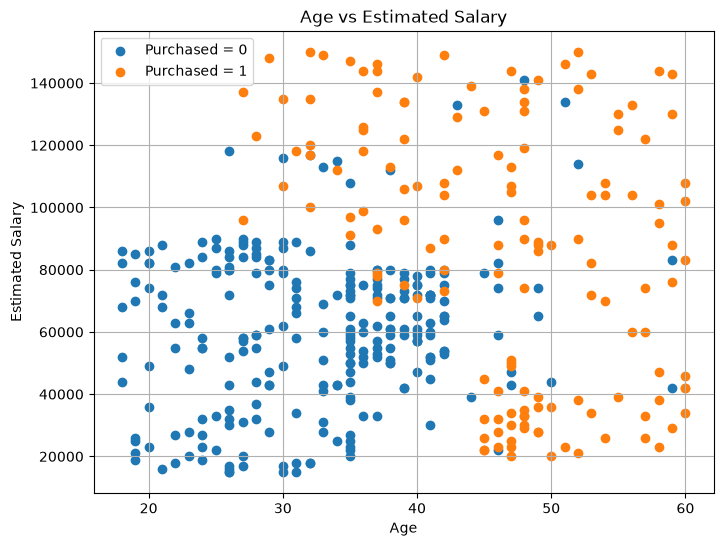

In [28]:
plt.figure(figsize=(8, 6))

for label in [0, 1]:

    data = df[df["Purchased"] == label]

    plt.scatter(
        data["Age"],
        data["EstimatedSalary"],
        label=f"Purchased = {label}"
    )

plt.xlabel("Age")
plt.ylabel("Estimated Salary")
plt.title("Age vs Estimated Salary")
plt.legend()
plt.savefig("Data Visualization")
plt.grid(True)

plt.show()

In [29]:
import numpy as np

class Node:

    def __init__(self,
                 feature=None,
                 threshold=None,
                 left=None,
                 right=None,
                 value=None):

        self.feature = feature
        self.threshold = threshold
        self.left = left
        self.right = right
        self.value = value

In [30]:
class DecisionTree:

    def __init__(self, max_depth=5, min_samples_split=2):

        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.root = None

    # Entropy


    def entropy(self, y):

        classes = np.unique(y)

        entropy = 0

        for c in classes:

            p = np.sum(y == c) / len(y)

            if p > 0:
                entropy -= p * np.log2(p)

        return entropy

    # Information Gain

    def information_gain(self, y, left_idx, right_idx):

        parent_entropy = self.entropy(y)

        n = len(y)

        n_left = len(left_idx)
        n_right = len(right_idx)

        if n_left == 0 or n_right == 0:
            return 0

        left_entropy = self.entropy(y[left_idx])
        right_entropy = self.entropy(y[right_idx])

        child_entropy = (
            (n_left / n) * left_entropy +
            (n_right / n) * right_entropy
        )

        return parent_entropy - child_entropy

    # Best Split
    def best_split(self, X, y):

        best_gain = -1
        split_feature = None
        split_threshold = None

        for feature in range(X.shape[1]):

            thresholds = np.unique(X[:, feature])

            for threshold in thresholds:

                left_idx = np.where(
                    X[:, feature] <= threshold
                )[0]

                right_idx = np.where(
                    X[:, feature] > threshold
                )[0]

                gain = self.information_gain(
                    y,
                    left_idx,
                    right_idx
                )

                if gain > best_gain:

                    best_gain = gain
                    split_feature = feature
                    split_threshold = threshold

        return split_feature, split_threshold

    # Build Tree
    def build_tree(self, X, y, depth=0):

        num_samples = len(y)
        num_classes = len(np.unique(y))

        if (
            depth >= self.max_depth or
            num_classes == 1 or
            num_samples < self.min_samples_split
        ):

            value = np.bincount(y).argmax()

            return Node(value=value)

        feature, threshold = self.best_split(X, y)

        left_idx = np.where(
            X[:, feature] <= threshold
        )[0]

        right_idx = np.where(
            X[:, feature] > threshold
        )[0]

        left = self.build_tree(
            X[left_idx],
            y[left_idx],
            depth + 1
        )

        right = self.build_tree(
            X[right_idx],
            y[right_idx],
            depth + 1
        )

        return Node(
            feature=feature,
            threshold=threshold,
            left=left,
            right=right
        )
    # Fit

    def fit(self, X, y):

        self.root = self.build_tree(X, y)

    # Predict Single

    def predict_sample(self, x, node):

        if node.value is not None:
            return node.value

        if x[node.feature] <= node.threshold:

            return self.predict_sample(
                x,
                node.left
            )

        return self.predict_sample(
            x,
            node.right
        )

    # Predict
    def predict(self, X):

        predictions = []

        for x in X:

            predictions.append(
                self.predict_sample(
                    x,
                    self.root
                )
            )

        return np.array(predictions)
    # Accuracy
    def accuracy(self, y_true, y_pred):

        return np.mean(y_true == y_pred)



In [31]:
#Train and Test split
np.random.seed(42)

indices = np.random.permutation(len(X))

train_size = int(0.8 * len(X))

train_indices = indices[:train_size]

test_indices = indices[train_size:]


X_train = X[train_indices]
X_test = X[test_indices]

y_train = y[train_indices]
y_test = y[test_indices]


print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 320
Testing samples: 80


In [32]:
# Predict One Sample
def predict_sample(self, x, node):

        # Leaf node
        if node.value is not None:
            return node.value

        # Go left
        if x[node.feature] <= node.threshold:

            return self.predict_sample(
                x,
                node.left
            )

        # Go right
        return self.predict_sample(
            x,
            node.right
        )

In [33]:
    def predict(self, X):

        predictions = []

        for x in X:

            predictions.append(
                self.predict_sample(
                    x,
                    self.root
                )
            )

        return np.array(predictions)

In [34]:
    def accuracy(self, y_true, y_pred):

        return np.mean(y_true == y_pred)

In [35]:
# CREATE MODEL
model = DecisionTree(
    max_depth=5,
    min_samples_split=2
)


In [36]:
model.fit(X_train, y_train)

In [37]:
y_pred = model.predict(X_test)

In [38]:
accuracy = model.accuracy(y_test,y_pred)
print("Accuracy:", accuracy)
print("Accuracy (%):", accuracy * 100)

Accuracy: 0.8625
Accuracy (%): 86.25


In [39]:
print("\nActual vs Predicted:")
for actual, predicted in zip(y_test, y_pred):
    print("Actual:",actual,"Predicted:",predicted
    )


Actual vs Predicted:
Actual: 0 Predicted: 1
Actual: 0 Predicted: 0
Actual: 1 Predicted: 1
Actual: 0 Predicted: 0
Actual: 1 Predicted: 1
Actual: 1 Predicted: 1
Actual: 1 Predicted: 0
Actual: 0 Predicted: 0
Actual: 0 Predicted: 1
Actual: 0 Predicted: 1
Actual: 0 Predicted: 0
Actual: 0 Predicted: 0
Actual: 0 Predicted: 0
Actual: 0 Predicted: 0
Actual: 1 Predicted: 1
Actual: 0 Predicted: 0
Actual: 0 Predicted: 0
Actual: 0 Predicted: 0
Actual: 0 Predicted: 0
Actual: 0 Predicted: 0
Actual: 0 Predicted: 1
Actual: 0 Predicted: 1
Actual: 0 Predicted: 0
Actual: 0 Predicted: 0
Actual: 1 Predicted: 1
Actual: 0 Predicted: 0
Actual: 0 Predicted: 0
Actual: 1 Predicted: 1
Actual: 0 Predicted: 0
Actual: 0 Predicted: 0
Actual: 1 Predicted: 0
Actual: 0 Predicted: 0
Actual: 1 Predicted: 1
Actual: 0 Predicted: 0
Actual: 1 Predicted: 0
Actual: 1 Predicted: 1
Actual: 0 Predicted: 0
Actual: 0 Predicted: 1
Actual: 1 Predicted: 1
Actual: 0 Predicted: 0
Actual: 1 Predicted: 1
Actual: 0 Predicted: 0
Actual: 0 Pr

In [40]:
# =====================================================
# PREDICT NEW CUSTOMER
# =====================================================

new_customer = np.array([[30, 100000]])

prediction = model.predict(new_customer)

print("\nNew Customer Prediction:", prediction)

if prediction[0] == 1:
    print("Customer is likely to purchase.")

else:
    print("Customer is unlikely to purchase.")


New Customer Prediction: [1]
Customer is likely to purchase.


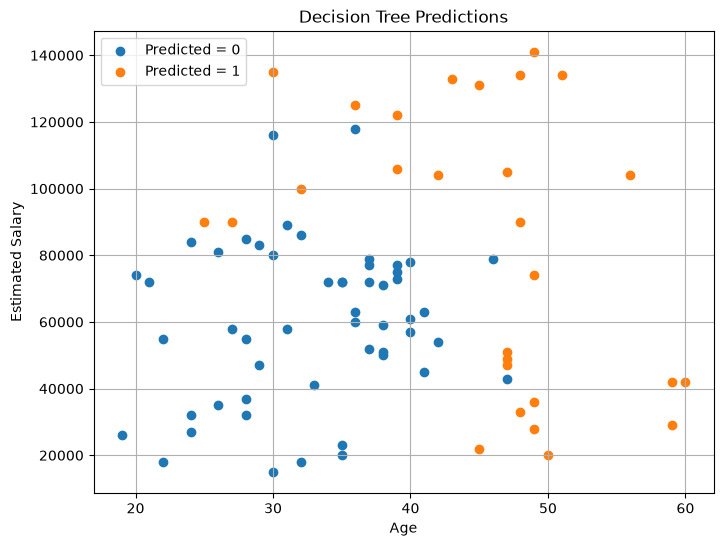

In [41]:
plt.figure(figsize=(8, 6))

for label in [0, 1]:

    data = X_test[y_pred == label]

    plt.scatter(
        data[:, 0],
        data[:, 1],
        label=f"Predicted = {label}"
    )

plt.xlabel("Age")
plt.ylabel("Estimated Salary")
plt.title("Decision Tree Predictions")
plt.savefig("Decision Tree Predictions")
plt.legend()
plt.grid(True)

plt.show()